In [28]:
# Libraries
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2")

---
## 1. Data Collection / Preparation


We first start off by pulling the API from Skinport.com, where the original file was given to us in `skinport_items.json`. We convert over to `skinport_items.csv`, for easier handling. Print the first few rows to see what columns we are working with, and select only useful data

---

In [29]:
# JSON taken from saving https://api.skinport.com/v1/sales/history?currency=USD

df = pd.read_json('data/skinport_items.json')
df.to_csv('data/skinport_items.csv', index=False)

# Identify the columns we want to keep
print(df.head())
print(df.columns) 




                             market_hash_name version currency  \
0  Sticker Slab | BIG (Gold) | Stockholm 2021     NaN      USD   
1  Sticker Slab | Kvik (Foil) | Katowice 2019     NaN      USD   
2         Sticker Slab | B1ad3 | Cologne 2015     NaN      USD   
3                   Sticker Slab | Pocket BBQ     NaN      USD   
4          Sticker Slab | oSee | Antwerp 2022     NaN      USD   

                                           item_page  \
0  https://skinport.com/item/sticker-slab-big-gol...   
1  https://skinport.com/item/sticker-slab-kvik-fo...   
2  https://skinport.com/item/sticker-slab-b1ad3-c...   
3  https://skinport.com/item/sticker-slab-pocket-bbq   
4  https://skinport.com/item/sticker-slab-osee-an...   

                                         market_page  \
0  https://skinport.com/market?item=BIG%20(Gold)%...   
1  https://skinport.com/market?item=Kvik%20(Foil)...   
2  https://skinport.com/market?item=B1ad3%20%7C%2...   
3  https://skinport.com/market?item=Pocket

---

# 1.1 Selecting Columns 

From the list of columns we have a total of 9 columns, `'market_hash_name', 'version', 'currency', 'item_page', 'market_page', 'last_24_hours', 'last_7_days', 'last_30_days', 'last_90_days'`. From, an initial glance, we can see that `'item_page'` and `'market_page'` are columns that link to a specific items store page, since we are interested in doing analysis on quantifiable data, we can drop those two columns. We are also only interested in the data of weapon skins for the past month (30 day), so we can drop all other time variables. We also drop `'currency'` (constant where every row is USD) and `'version'` (~98% missing). Since our goal is useable predictors in MLR, we drop `'currency'` and `'version'` because they provide no predictive value.

---

In [30]:
#Creating a temporary cleaned data frame with only columns we want to keep for analysis
df_cleaned_temp = df.drop(columns=[
    "item_page",
    "market_page",
    "last_24_hours",
    "last_7_days",
    "last_90_days",
    "version",
    "currency"
])

print(df_cleaned_temp.shape)
df_cleaned_temp.head()

(33855, 2)


,market_hash_name,last_30_days
0,Sticker Slab | BIG (Gold) | Stockholm 2021,"{'min': None, 'max': None, 'avg': None, 'media..."
1,Sticker Slab | Kvik (Foil) | Katowice 2019,"{'min': None, 'max': None, 'avg': None, 'media..."
2,Sticker Slab | B1ad3 | Cologne 2015,"{'min': None, 'max': None, 'avg': None, 'media..."
3,Sticker Slab | Pocket BBQ,"{'min': None, 'max': None, 'avg': None, 'media..."
4,Sticker Slab | oSee | Antwerp 2022,"{'min': None, 'max': None, 'avg': None, 'media..."


---

Notice that `'last_30_days'` is a dictionary containing `'min'`, `'max'`, `'avg'`, `'median'`, `'volume'`. We can extract this out into columns for our cleaned data frame.

---

In [31]:
last_30_days = pd.json_normalize(df['last_30_days']) # expand the dictionary of last_30_days into a temporary data frame

df_cleaned_temp = df_cleaned_temp.join(last_30_days)
df_cleaned_temp = df_cleaned_temp.drop(columns='last_30_days')

df_cleaned_temp.head()

,market_hash_name,min,max,avg,median,volume
0,Sticker Slab | BIG (Gold) | Stockholm 2021,NaN,NaN,NaN,NaN,0
1,Sticker Slab | Kvik (Foil) | Katowice 2019,NaN,NaN,NaN,NaN,0
2,Sticker Slab | B1ad3 | Cologne 2015,NaN,NaN,NaN,NaN,0
3,Sticker Slab | Pocket BBQ,NaN,NaN,NaN,NaN,0
4,Sticker Slab | oSee | Antwerp 2022,NaN,NaN,NaN,NaN,0


---

Next check for missing data 

---

                  Missing Values  Percent Missing
market_hash_name               0         0.000000
min                        16205        47.865899
max                        16205        47.865899
avg                        16205        47.865899
median                     16205        47.865899
volume                         0         0.000000


<Axes: >

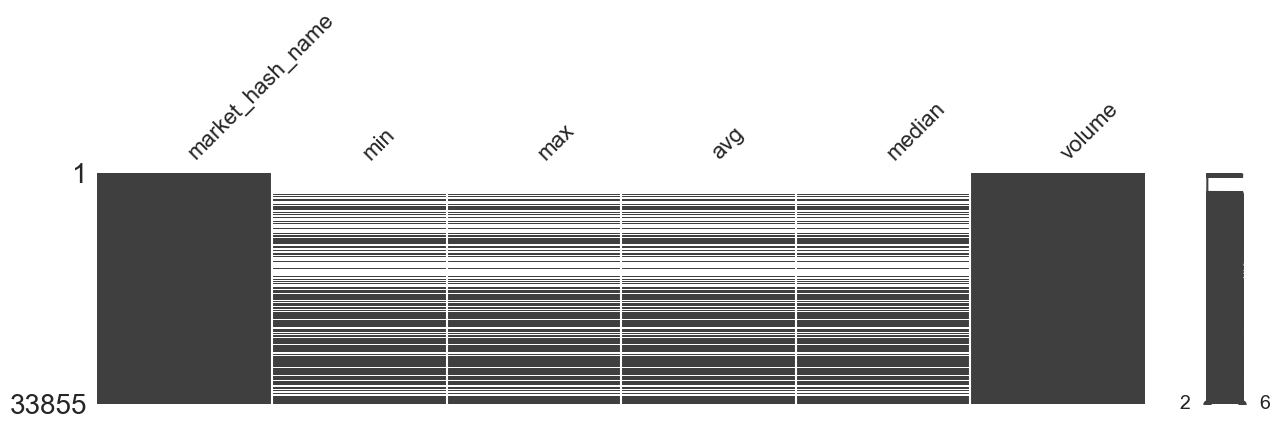

In [32]:
missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(missing_table)


# We can visualize the missing data with missingno
msno.matrix(df_cleaned_temp, figsize=(15, 3)) 

---

Note: All the missing data seems to be all from the same entries, so we will remove rows where every statistic is missing

---

In [33]:
# Remove rows where every statistic is missing
df_cleaned_temp = df_cleaned_temp.dropna(subset=["min", "max", "avg", "median"], how="all") # version is not dropped as None *is* a valid version rather than representing null

new_missing_table = pd.DataFrame({
        'Missing Values': df_cleaned_temp.isna().sum(), 
        'Percent Missing': df_cleaned_temp.isna().mean() * 100
    })

print(new_missing_table)
print(df_cleaned_temp.shape) # removed exactly 16205 entires, as expected
df_cleaned_temp.head()

                  Missing Values  Percent Missing
market_hash_name               0              0.0
min                            0              0.0
max                            0              0.0
avg                            0              0.0
median                         0              0.0
volume                         0              0.0
(17650, 6)


,market_hash_name,min,max,avg,median,volume
210,Souvenir AK-47 | Steel Delta (Field-Tested),4.06,8.61,5.35,4.87,7
332,Souvenir XM1014 | Hieroglyph (Factory New),0.56,1.20,0.99,1.04,6
343,Souvenir MAG-7 | Copper Coated (Field-Tested),0.35,1.16,0.59,0.44,4
580,Souvenir P90 | ScaraB Rush (Well-Worn),4.92,4.92,4.92,4.92,1
2795,AK-47 | Black Laminate (Well-Worn),58.03,58.03,58.03,58.03,1


---

From `'market_hash_name'` we get a lot of information regarding a specific skin that can affect it's pricing, such as `Souvenir` status,  `StatTrak™` status, `skin names` and item `condition`. We can break `market_hash_name` into seperate categorical variables. 

We also want to look at the most common used weapons in the game, as those weapons have more "value" due to popularity, so we filter by those weapons, which would include the `AK-47`, `M4A1-S`, `M4A4`, and `AWP`.

---

In [34]:
# create new columns souvenir and stat_trak

df_cleaned_temp["souvenir"] = df_cleaned_temp["market_hash_name"].str.contains("Souvenir")
df_cleaned_temp["stat_trak"] = df_cleaned_temp["market_hash_name"].str.contains("StatTrak")

#filtering 4 most popular guns for analysis

temp_df = df_cleaned_temp[df_cleaned_temp["market_hash_name"].str.contains("AK-47|M4A1-S|M4A4|AWP")]

temp_df.head()
df_cleaned = temp_df
df_cleaned.head()

,market_hash_name,min,max,avg,median,volume,souvenir,stat_trak
210,Souvenir AK-47 | Steel Delta (Field-Tested),4.06,8.61,5.35,4.87,7,True,False
2795,AK-47 | Black Laminate (Well-Worn),58.03,58.03,58.03,58.03,1,False,False
2813,AK-47 | Aquamarine Revenge (Battle-Scarred),27.33,35.98,32.02,31.67,7,False,False
2814,AK-47 | Fire Serpent (Factory New),2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47 | Predator (Battle-Scarred),9.23,9.68,9.46,9.45,2,False,False


---

We can now break apart `'market_has_name'` into seperate variables (`weapon`, `skin_name`, `condition`).

---

In [35]:
# seperate market hash name into different variables
df_cleaned[['weapon', 'skin_name', 'condition']] = df_cleaned['market_hash_name'].str.extract(r'(.+?)\s*\|\s*(.+?)\s*\((.+?)\)', expand=True)

# Remove souvenir / StatTrak from weapon names since we already have tuples categories
df_cleaned['weapon'] = df_cleaned['weapon'].str.replace(
    r"(Souvenir\s+|StatTrak™?\s+)",
    "",
    regex=True
).str.strip()

df_cleaned=df_cleaned.drop(columns='market_hash_name')
df_cleaned.head()

,min,max,avg,median,volume,souvenir,stat_trak,weapon,skin_name,condition
210,4.06,8.61,5.35,4.87,7,True,False,AK-47,Steel Delta,Field-Tested
2795,58.03,58.03,58.03,58.03,1,False,False,AK-47,Black Laminate,Well-Worn
2813,27.33,35.98,32.02,31.67,7,False,False,AK-47,Aquamarine Revenge,Battle-Scarred
2814,2485.40,2625.52,2555.46,2555.46,2,False,False,AK-47,Fire Serpent,Factory New
2908,9.23,9.68,9.46,9.45,2,False,False,AK-47,Predator,Battle-Scarred


---

Reorder Columns for better readability.

---

In [36]:
first_cols = ["weapon", "skin_name", "condition"]
other_cols = [col for col in df_cleaned.columns if col not in first_cols]

df_cleaned = df_cleaned[first_cols + other_cols]

df_cleaned.head()

,weapon,skin_name,condition,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,Field-Tested,4.06,8.61,5.35,4.87,7,True,False
2795,AK-47,Black Laminate,Well-Worn,58.03,58.03,58.03,58.03,1,False,False
2813,AK-47,Aquamarine Revenge,Battle-Scarred,27.33,35.98,32.02,31.67,7,False,False
2814,AK-47,Fire Serpent,Factory New,2485.40,2625.52,2555.46,2555.46,2,False,False
2908,AK-47,Predator,Battle-Scarred,9.23,9.68,9.46,9.45,2,False,False


---

For analysis we typically want quantifiable variables and numeric values. In Counter-Strike 2, weapon conditions can affect a skins price, so we can assign corresponding condition values to every possible weapon condition. Since we are converting character values into numeric variables, we might as well convert our boolean variables `'souvenir'` and `'stat_trak'` into binary values for easier analysis as well.

---

In [37]:
# Convert souvenir and stat_trak boolean status to binary for regression purposes
df_cleaned["souvenir"] = df_cleaned["souvenir"].astype(int)
df_cleaned["stat_trak"] = df_cleaned["stat_trak"].astype(int)


# map values to condition for linear regression purposes
condition_codes = {
    "Factory New": 4, 
    "Minimal Wear": 3, 
    "Field-Tested": 2,
    "Well-Worn": 1, 
    "Battle-Scarred": 0,
}

# recode condition categories
df_cleaned_enc = df_cleaned.replace({'condition': condition_codes})

df = df_cleaned_enc

df.head()

,weapon,skin_name,condition,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,9.23,9.68,9.46,9.45,2,0,0


---

Finally, we drop rows whose `'condition'` isn't one of our five wear tiers. These are items whose parenthetical wasn't a wear tier usually due to special characters (e.g. `'M4A4 | 龍王 (Dragon King)'`), plus stickers/graffiti and unparsed rows that slipped through the weapon filter.

---

In [38]:
print("Before:", df.shape)

# keep only rows where condition is one of our 5 wear tiers (0-4)
df = df[df["condition"].isin([0, 1, 2, 3, 4])]
df["condition"] = df["condition"].astype(int)

print("After: ", df.shape)
print(df["weapon"].value_counts())   # sanity check: should be just the 4 weapons
df.head()


Before: (1469, 10)
After:  (1445, 10)
weapon
AK-47     455
AWP       339
M4A4      337
M4A1-S    314
Name: count, dtype: int64


,weapon,skin_name,condition,min,max,avg,median,volume,souvenir,stat_trak
210,AK-47,Steel Delta,2,4.06,8.61,5.35,4.87,7,1,0
2795,AK-47,Black Laminate,1,58.03,58.03,58.03,58.03,1,0,0
2813,AK-47,Aquamarine Revenge,0,27.33,35.98,32.02,31.67,7,0,0
2814,AK-47,Fire Serpent,4,2485.40,2625.52,2555.46,2555.46,2,0,0
2908,AK-47,Predator,0,9.23,9.68,9.46,9.45,2,0,0


---

Now we have the completed cleaned our data for analysis, we can convert it into a csv file(`skinport_items_cleaned(1).csv`) for others to use.

---

In [39]:
# write to csv for others to use

df.to_csv('data/skinport_items_cleaned(1).csv', index=False)